# Capstone Project - Classification: Telco Customer Churn

**Course:** Data Mining & Information Visualization  
**Project type:** Classification (categorical target)  
**Dataset:** IBM Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)  
**Target variable:** `Churn` (`Yes` / `No`)

### Workflow covered (per Capstone requirements)
Dataset Selection -> Data Understanding -> Preprocessing -> Data Balancing -> Feature Selection -> Model Selection -> Training -> Validation -> Testing -> Evaluation -> Visualization -> Interpretation

## 1. Problem Statement & Dataset Selection

**Problem:** Predict whether a telecom customer will churn (leave the service).

**Why classification?** The target `Churn` is a categorical binary label (`Yes`/`No`), so this is a supervised classification task.

**Business value:** Identify customers at risk of leaving so retention offers, support outreach, and contract changes can be targeted.

## 2. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

## 3. Data Understanding & Exploration

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes.value_counts())
print("\nChurn distribution:")
print(df["Churn"].value_counts())
print("\nChurn rate:")
print(df["Churn"].value_counts(normalize=True).round(3))
df.head()

Shape: (7043, 21)

Data types:
object     18
int64       2
float64     1
Name: count, dtype: int64

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Fix TotalCharges: stored as object with blank strings for new customers
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after TotalCharges conversion:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nBasic stats for numeric columns:")
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

Missing values after TotalCharges conversion:
TotalCharges    11
dtype: int64

Basic stats for numeric columns:


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


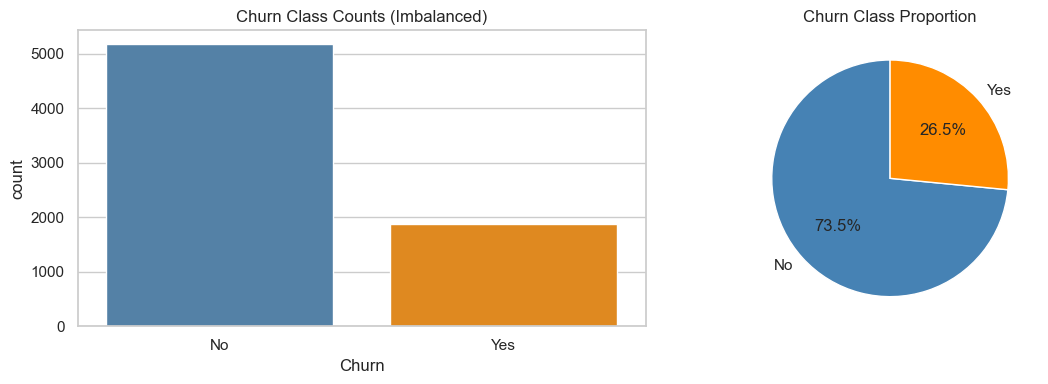

In [4]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="Churn", ax=axes[0], palette=["steelblue", "darkorange"])
axes[0].set_title("Churn Class Counts (Imbalanced)")
churn_pct = df["Churn"].value_counts(normalize=True)
axes[1].pie(churn_pct, labels=churn_pct.index, autopct="%1.1f%%",
            colors=["steelblue", "darkorange"], startangle=90)
axes[1].set_title("Churn Class Proportion")
plt.tight_layout()
plt.show()

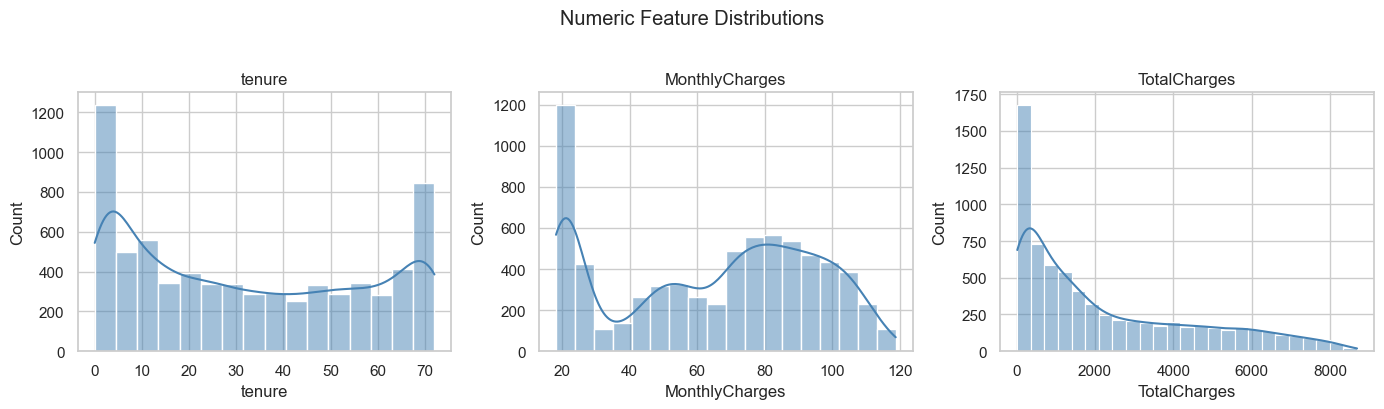

In [5]:
# Numeric distributions
num_explore = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_explore):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

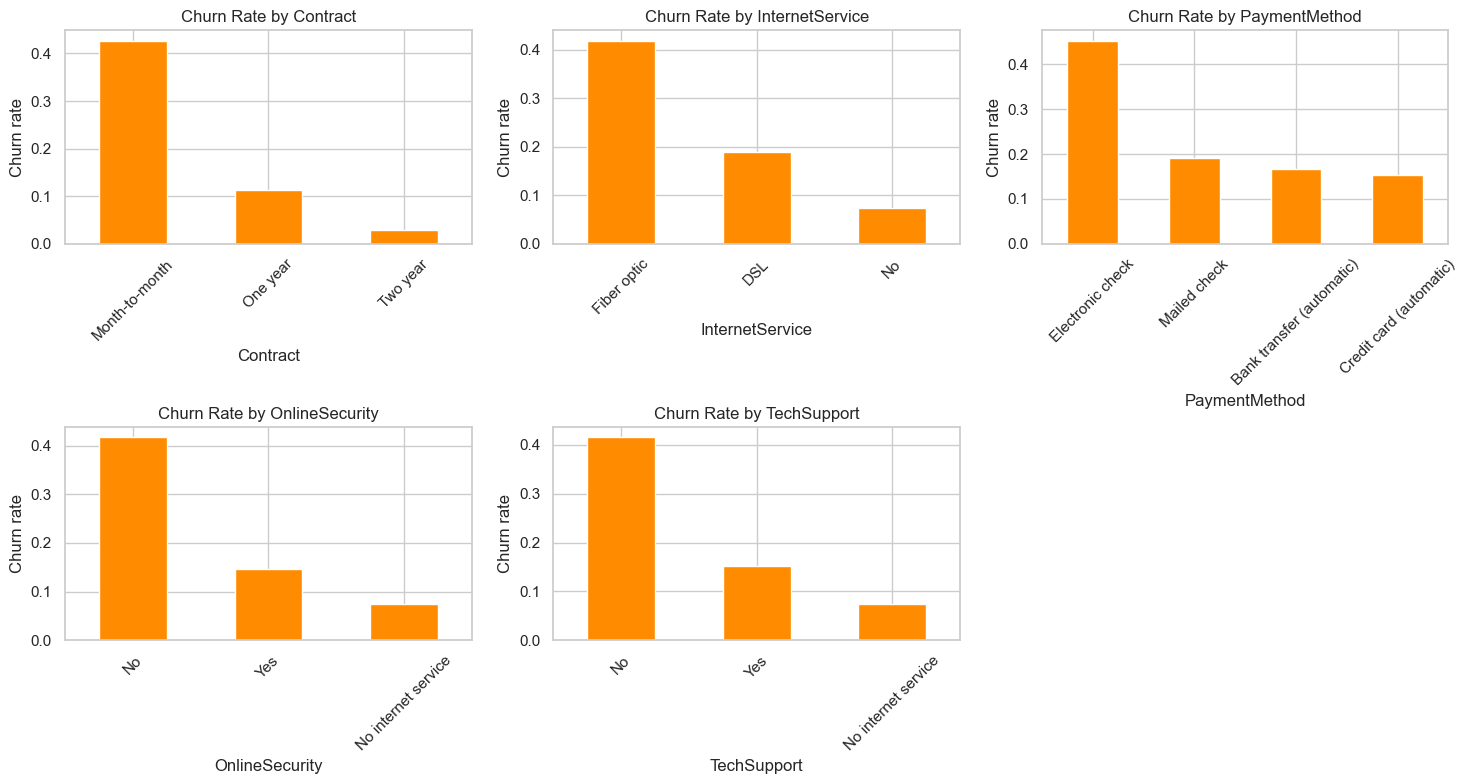

In [6]:
# Churn rate by key categorical features
cat_explore = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, col in enumerate(cat_explore):
    rates = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)
    rates.plot(kind="bar", ax=axes[i], color="darkorange")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn rate")
    axes[i].tick_params(axis="x", rotation=45)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

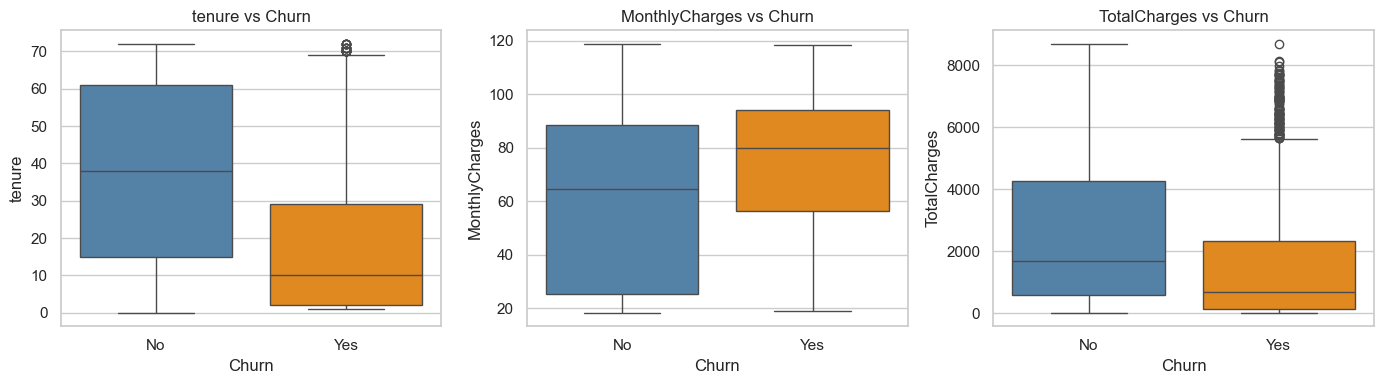

In [7]:
# Numeric features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_explore):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax, palette=["steelblue", "darkorange"])
    ax.set_title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

### Exploration insights
- Classes are **imbalanced** (~73% No, ~27% Yes) -> balancing will be required.
- Month-to-month contracts, fiber optic, and electronic check payment often show higher churn.
- Lower tenure and higher monthly charges are commonly associated with churn.

## 4. Data Preprocessing

**Actions:**
- Drop `customerID` (identifier only)
- Convert `TotalCharges` to numeric; impute remaining nulls with median
- Encode target `Churn` as 1=Yes, 0=No
- Impute + scale numeric features
- One-hot encode categorical features

In [8]:
data = df.copy()
data = data.drop(columns=["customerID"])

# Target encoding
le = LabelEncoder()
y = le.fit_transform(data["Churn"])  # Yes=1, No=0 after alphabetical? check
# Ensure Yes=1
if list(le.classes_) == ["No", "Yes"]:
    # LabelEncoder sorts alphabetically: No=0, Yes=1  -> correct
    pass
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

X = data.drop(columns=["Churn"])

# SeniorCitizen is already 0/1 numeric; treat as categorical for clarity
X["SeniorCitizen"] = X["SeniorCitizen"].astype(str)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

print(f"Numeric: {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")
print(f"Positive class rate: {y.mean():.3f}")

Classes: {'No': 0, 'Yes': 1}
Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Positive class rate: 0.265


In [9]:
# Stratified train / validation / test split (~70 / 15 / 15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")
print(f"Train churn rate: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

Train: 4929 | Val: 1057 | Test: 1057
Train churn rate: 0.265 | Val: 0.266 | Test: 0.265


## 5. Data Balancing

Because churners are the minority class, we apply **SMOTE** on the training fold only
(after preprocessing) to avoid leakage into validation/test.

Features after preprocessing: 46
Before SMOTE: [3621 1308]
After SMOTE: [3621 3621]


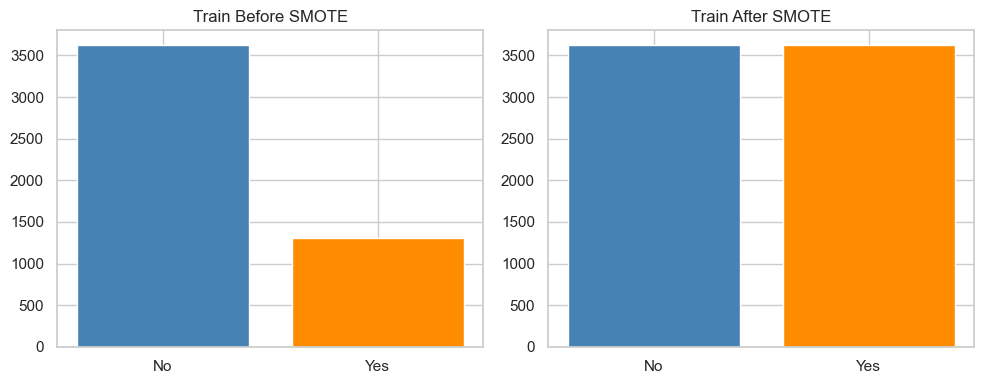

In [10]:
# Fit preprocessor on train only
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print(f"Features after preprocessing: {len(feature_names)}")

print("Before SMOTE:", np.bincount(y_train))
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)
print("After SMOTE:", np.bincount(y_train_bal))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["No", "Yes"], np.bincount(y_train), color=["steelblue", "darkorange"])
axes[0].set_title("Train Before SMOTE")
axes[1].bar(["No", "Yes"], np.bincount(y_train_bal), color=["steelblue", "darkorange"])
axes[1].set_title("Train After SMOTE")
plt.tight_layout()
plt.show()

## 6. Feature Selection

Use mutual information (classification) to keep the most informative encoded features.

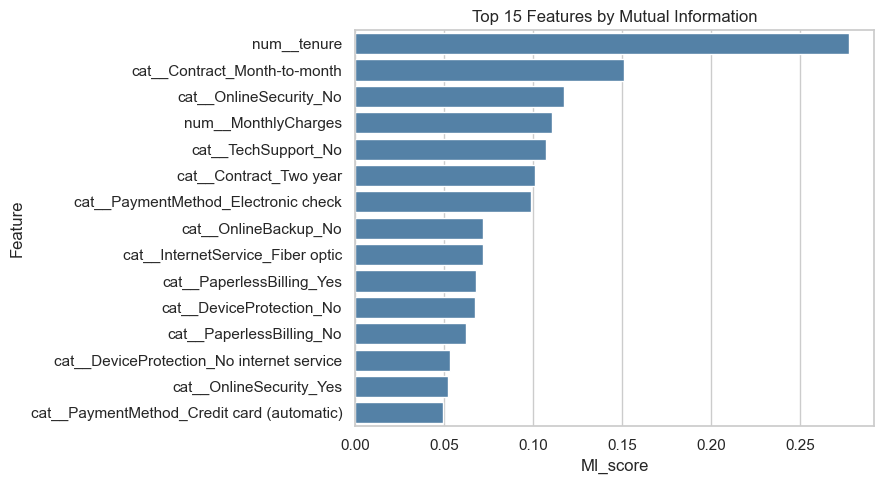

,Feature,MI_score
0,num__tenure,0.277762
37,cat__Contract_Month-to-month,0.151168
19,cat__OnlineSecurity_No,0.117222
1,num__MonthlyCharges,0.110466
28,cat__TechSupport_No,0.107453
39,cat__Contract_Two year,0.100991
44,cat__PaymentMethod_Electronic check,0.098637
22,cat__OnlineBackup_No,0.071787
17,cat__InternetService_Fiber optic,0.071659
41,cat__PaperlessBilling_Yes,0.067812


In [11]:
k = min(40, X_train_bal.shape[1])
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_sel = selector.fit_transform(X_train_bal, y_train_bal)
X_val_sel = selector.transform(X_val_prep)
X_test_sel = selector.transform(X_test_prep)

selected_features = feature_names[selector.get_support()]
scores = pd.DataFrame({
    "Feature": feature_names,
    "MI_score": selector.scores_
}).sort_values("MI_score", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=scores.head(15), y="Feature", x="MI_score", color="steelblue")
plt.title("Top 15 Features by Mutual Information")
plt.tight_layout()
plt.show()
scores.head(15)

**Justification:** Mutual information captures nonlinear associations with churn after one-hot encoding, reduces noise, and keeps features most useful for class separation.

## 7. Model / Algorithm Selection

| Model | Why selected |
|-------|----------------|
| **Logistic Regression** | Strong linear baseline; interpretable coefficients |
| **Decision Tree** | Nonlinear splits; easy to overfit - useful contrast |
| **Random Forest** | Robust bagged trees |
| **Gradient Boosting** | Strong tabular classifier |

Primary metric emphasis: **Recall / F1 / ROC-AUC** for the churn (Yes) class, because missing a churner is costly.

In [12]:
def classification_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
    }

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    ),
}

## 8. Training & Validation

In [13]:
val_results = {}
fitted_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Validation performance\n" + "-" * 72)
for name, model in models.items():
    model.fit(X_train_sel, y_train_bal)
    fitted_models[name] = model

    y_val_pred = model.predict(X_val_sel)
    y_val_prob = model.predict_proba(X_val_sel)[:, 1]
    metrics = classification_metrics(y_val, y_val_pred, y_val_prob)
    val_results[name] = metrics

    cv_auc = cross_val_score(
        model, X_train_sel, y_train_bal, cv=cv, scoring="roc_auc", n_jobs=-1
    ).mean()

    print(f"{name:20s} | Acc={metrics['Accuracy']:.3f} | Prec={metrics['Precision']:.3f} | "
          f"Rec={metrics['Recall']:.3f} | F1={metrics['F1']:.3f} | "
          f"AUC={metrics['ROC_AUC']:.3f} | CV AUC={cv_auc:.3f}")

df_val = pd.DataFrame(val_results).T.sort_values("F1", ascending=False)
df_val

Validation performance
------------------------------------------------------------------------
Logistic Regression  | Acc=0.752 | Prec=0.523 | Rec=0.769 | F1=0.622 | AUC=0.830 | CV AUC=0.859
Decision Tree        | Acc=0.761 | Prec=0.541 | Rec=0.662 | F1=0.595 | AUC=0.802 | CV AUC=0.867
Random Forest        | Acc=0.789 | Prec=0.603 | Rec=0.605 | F1=0.604 | AUC=0.824 | CV AUC=0.927
Gradient Boosting    | Acc=0.788 | Prec=0.592 | Rec=0.651 | F1=0.620 | AUC=0.836 | CV AUC=0.927


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.752129,0.523002,0.768683,0.622478,0.829668
Gradient Boosting,0.788079,0.592233,0.651246,0.620339,0.835712
Random Forest,0.789026,0.602837,0.604982,0.603908,0.823596
Decision Tree,0.760643,0.540698,0.661922,0.595200,0.802363


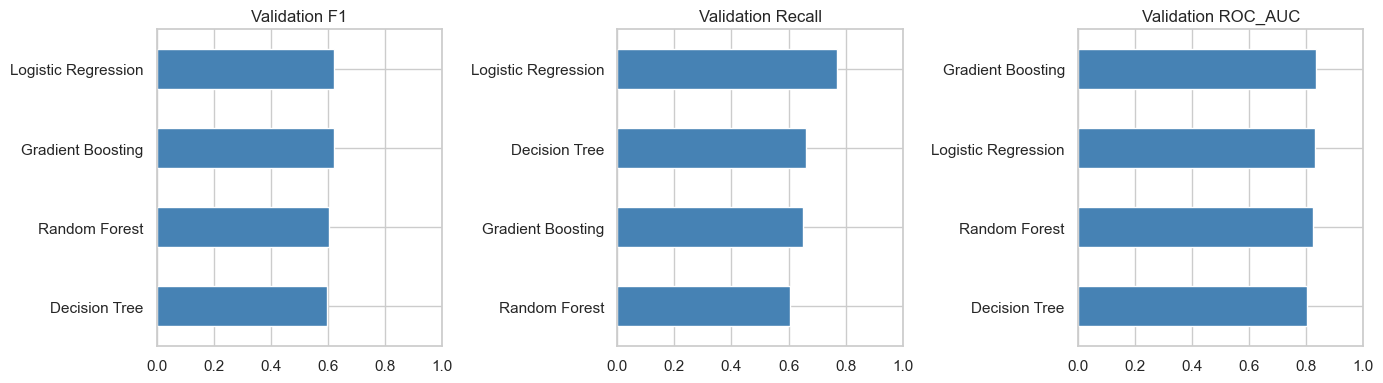

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["F1", "Recall", "ROC_AUC"]):
    df_val[metric].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Validation {metric}")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 9. Testing

Select the best model by validation **F1** (balance of precision & recall for churn),
refit on train+validation (with SMOTE on combined labeled train data), then evaluate on held-out test.

In [15]:
best_name = df_val["F1"].idxmax()
print(f"Best model by validation F1: {best_name}")

# Rebuild selected features on train+val, then SMOTE, then final fit
X_trainval_prep = np.concatenate([X_train_prep, X_val_prep], axis=0)
y_trainval = np.concatenate([y_train, y_val])

# Re-fit selector on original (pre-SMOTE) train+val for consistent transform,
# then SMOTE the selected training matrix used for final model.
selector_final = SelectKBest(score_func=mutual_info_classif, k=k)
X_trainval_sel_raw = selector_final.fit_transform(X_trainval_prep, y_trainval)
X_test_sel_final = selector_final.transform(X_test_prep)
selected_features = feature_names[selector_final.get_support()]

smote_final = SMOTE(random_state=RANDOM_STATE)
X_trainval_bal, y_trainval_bal = smote_final.fit_resample(X_trainval_sel_raw, y_trainval)

final_model = models[best_name].__class__(**models[best_name].get_params())
final_model.fit(X_trainval_bal, y_trainval_bal)

y_test_pred = final_model.predict(X_test_sel_final)
y_test_prob = final_model.predict_proba(X_test_sel_final)[:, 1]
test_metrics = classification_metrics(y_test, y_test_pred, y_test_prob)

print("\nFinal TEST performance (best model):")
for k_, v in test_metrics.items():
    print(f"  {k_}: {v:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_test_pred, target_names=["No Churn", "Churn"]))

Best model by validation F1: Logistic Regression

Final TEST performance (best model):
  Accuracy: 0.7540
  Precision: 0.5229
  Recall: 0.8143
  F1: 0.6369
  ROC_AUC: 0.8482

Classification report:
              precision    recall  f1-score   support

    No Churn       0.92      0.73      0.81       777
       Churn       0.52      0.81      0.64       280

    accuracy                           0.75      1057
   macro avg       0.72      0.77      0.73      1057
weighted avg       0.81      0.75      0.77      1057



## 10. Model Evaluation - All Models on Test Set

In [16]:
test_results = {}
fitted_final = {}
for name, base in models.items():
    m = base.__class__(**base.get_params())
    m.fit(X_trainval_bal, y_trainval_bal)
    pred = m.predict(X_test_sel_final)
    prob = m.predict_proba(X_test_sel_final)[:, 1]
    test_results[name] = classification_metrics(y_test, pred, prob)
    fitted_final[name] = m

df_test = pd.DataFrame(test_results).T.sort_values("F1", ascending=False)
print("Test-set Model Comparison\n")
print(df_test.round(4))
df_test

Test-set Model Comparison

                     Accuracy  Precision  Recall      F1  ROC_AUC
Logistic Regression    0.7540     0.5229  0.8143  0.6369   0.8482
Gradient Boosting      0.7758     0.5620  0.6964  0.6220   0.8504
Decision Tree          0.7427     0.5098  0.7464  0.6058   0.8059
Random Forest          0.7758     0.5674  0.6464  0.6043   0.8325


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.754021,0.522936,0.814286,0.636872,0.848200
Gradient Boosting,0.775781,0.561960,0.696429,0.622010,0.850427
Decision Tree,0.742668,0.509756,0.746429,0.605797,0.805934
Random Forest,0.775781,0.567398,0.646429,0.604341,0.832481


## 11. Information Visualizations (Classification-focused)

Capstone-relevant plots: **confusion matrix**, **ROC**, **PR curve**, **feature importance**.

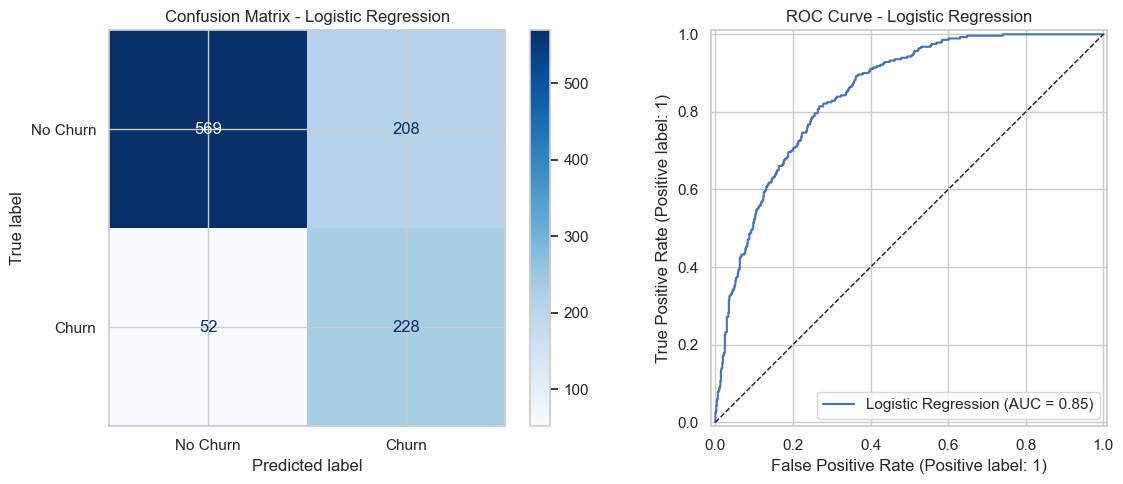

In [17]:
final_name = df_test["F1"].idxmax()
final_model = fitted_final[final_name]
y_hat = final_model.predict(X_test_sel_final)
y_prob = final_model.predict_proba(X_test_sel_final)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_hat, display_labels=["No Churn", "Churn"], ax=axes[0], cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix - {final_name}")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=final_name)
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title(f"ROC Curve - {final_name}")
plt.tight_layout()
plt.show()

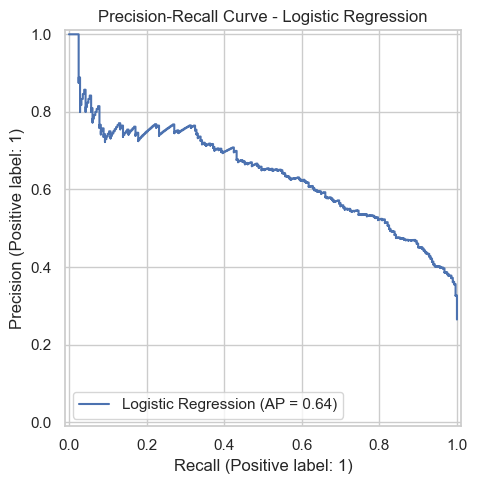

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax, name=final_name)
ax.set_title(f"Precision-Recall Curve - {final_name}")
plt.tight_layout()
plt.show()

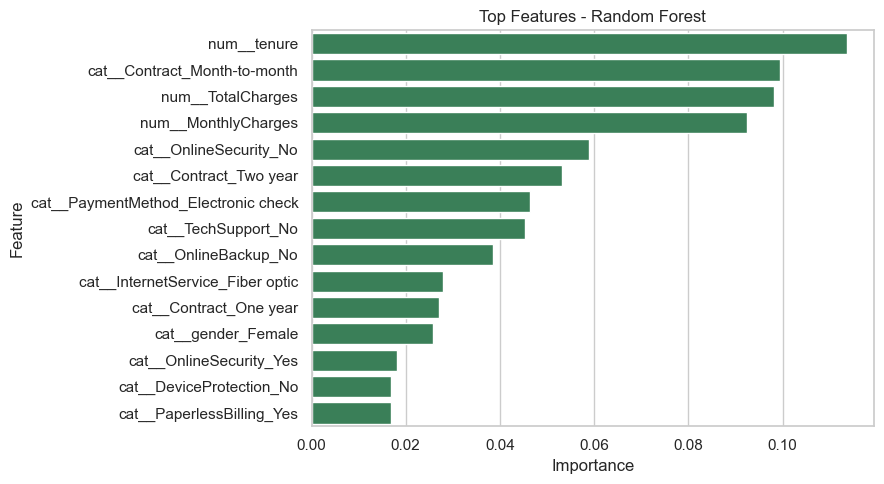

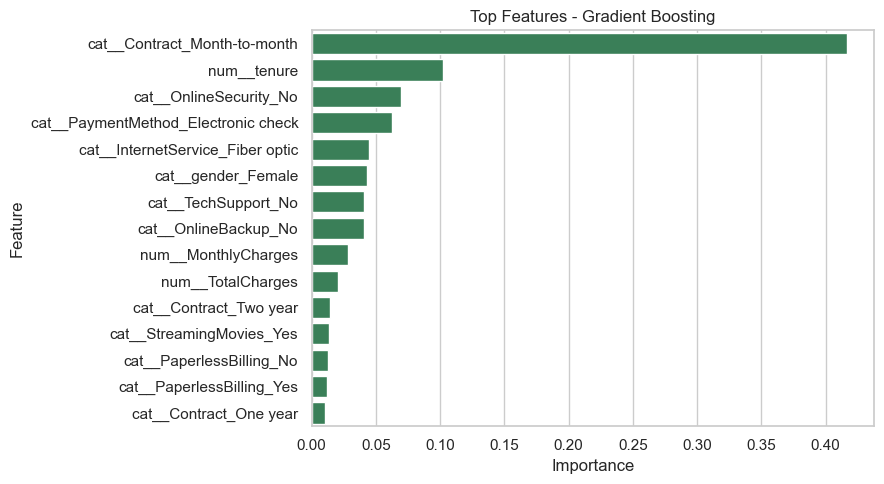

Top |Coefficients| - Logistic Regression: no feature_importances_ (e.g. linear model uses coefficients)


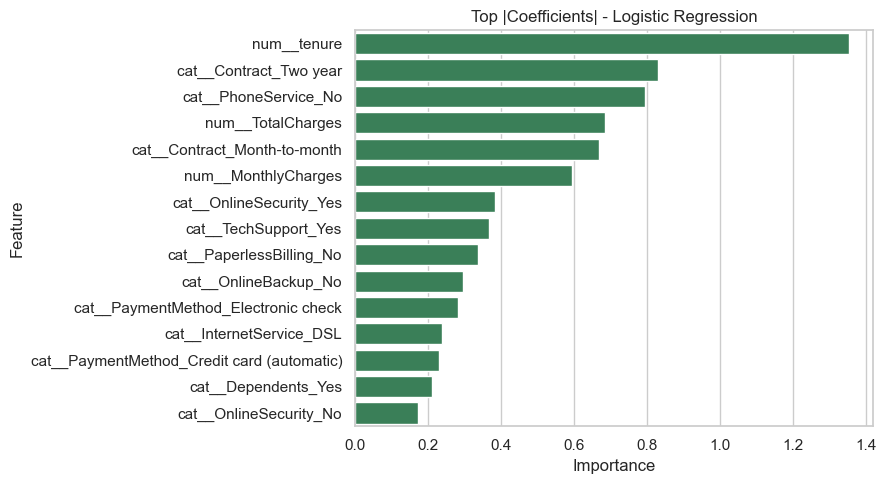

In [19]:
def plot_importance(model, title, top_n=15):
    if not hasattr(model, "feature_importances_"):
        print(f"{title}: no feature_importances_ (e.g. linear model uses coefficients)")
        if hasattr(model, "coef_"):
            imp = pd.DataFrame({
                "Feature": selected_features,
                "Importance": np.abs(model.coef_.ravel())
            }).sort_values("Importance", ascending=False).head(top_n)
        else:
            return None
    else:
        imp = pd.DataFrame({
            "Feature": selected_features,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=imp, y="Feature", x="Importance", color="seagreen")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return imp

_ = plot_importance(fitted_final["Random Forest"], "Top Features - Random Forest")
_ = plot_importance(fitted_final["Gradient Boosting"], "Top Features - Gradient Boosting")
_ = plot_importance(fitted_final["Logistic Regression"], "Top |Coefficients| - Logistic Regression")

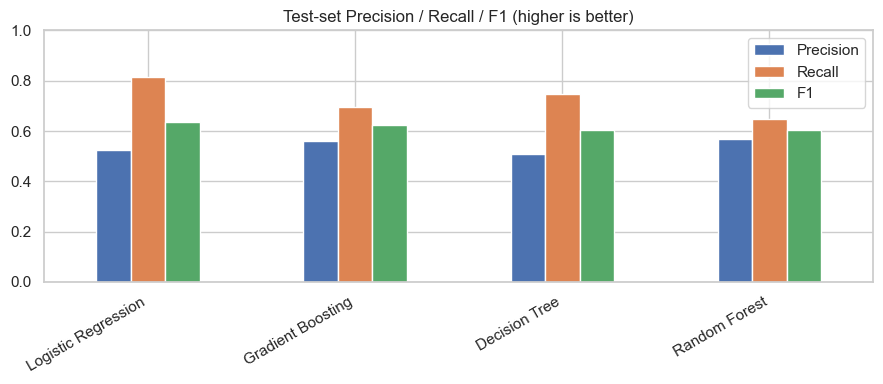

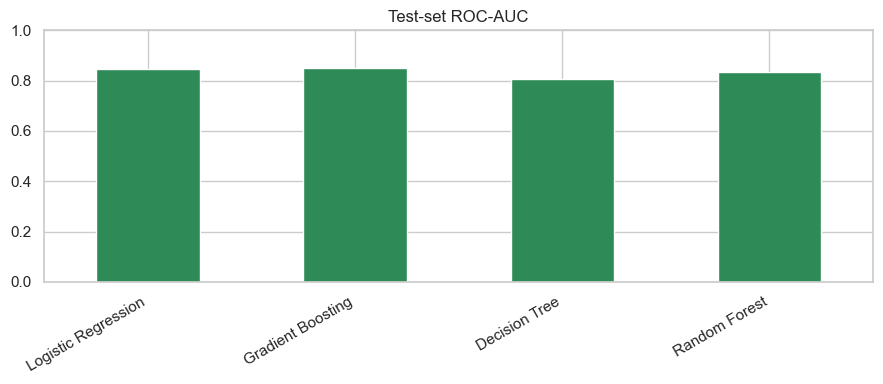

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
df_test[["Precision", "Recall", "F1"]].plot(kind="bar", ax=ax)
ax.set_title("Test-set Precision / Recall / F1 (higher is better)")
ax.set_ylim(0, 1)
ax.set_xticklabels(df_test.index, rotation=30, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
df_test["ROC_AUC"].plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Test-set ROC-AUC")
ax.set_ylim(0, 1)
ax.set_xticklabels(df_test.index, rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 12. Interpretation of Results

### Metrics meaning
- **Accuracy:** overall correct predictions (can look high with imbalance)
- **Precision:** of predicted churners, how many truly churn
- **Recall:** of actual churners, how many we catch (critical for retention)
- **F1:** harmonic mean of precision and recall
- **ROC-AUC:** ranking quality across thresholds

### Expected findings on this dataset
1. Class imbalance makes accuracy alone misleading - F1/Recall/AUC matter more.
2. Contract type, tenure, internet service, and payment method usually drive churn risk.
3. Tree ensembles often compete strongly with logistic regression on tabular churn data.
4. Confusion matrix shows the trade-off between false alarms and missed churners.

### Decision-making value
- Retention teams can prioritize high-probability churners for offers/calls.
- Product/pricing can focus on month-to-month and high-charge segments.
- Support can improve security/tech-support attachments linked to lower churn.

## 13. Conclusions & Recommendations

1. Telco churn prediction is correctly framed as a **binary classification** problem.
2. Full Capstone workflow applied, including **SMOTE balancing** because of class imbalance.
3. Best model should be chosen primarily by **F1 / Recall / ROC-AUC**, not accuracy alone.
4. Key actionable drivers typically include **contract type, tenure, internet service, and charges**.
5. Recommended next steps: threshold tuning for business cost, richer tenure-binned features,
   and monitoring model drift over time.